# 04 — Validation & Baselines

Model performance validation beyond aggregate metrics. Answers three questions:

1. **Confusion matrix** — Where does the classifier make mistakes? (false positives vs false negatives)
2. **Calibration** — When the model says "70 % chance of long stay", is it really 70 %?
3. **Baselines** — How much better are ML models than a naive mean predictor?

**Sections:**
1. Setup + mean predictor baseline
2. Confusion matrices (default 0.5 + optimal F1 threshold)
3. Classification report (precision / recall / F1 per class)
4. Calibration plots
5. Final comparison table — all models vs mean baseline

In [1]:
SOURCE = "mimic4"

import sys, json
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    precision_recall_curve, f1_score,
)
from sklearn.calibration import CalibrationDisplay

from src.config import FIGURES_DIR, MODELS_DIR, RANDOM_SEED, TARGET
from src.data.load import load_icu_stays
from src.features.build import split_xy
from src.models.train import prepare_target, to_days, LONG_STAY_DAYS

sns.set_theme(style="whitegrid", context="notebook")

# Load data + same train/test split as training
df = load_icu_stays(SOURCE)
X, y_raw, numeric_cols, categorical_cols = split_xy(df)

# Regression split
y_reg = prepare_target(y_raw, "regression")
X_tr, X_te, y_tr_reg, y_te_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_SEED,
)
y_te_days = to_days(y_te_reg, "regression")

# Classification split (stratified)
y_clf = prepare_target(y_raw, "classification")
X_tr_c, X_te_c, y_tr_clf, y_te_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_SEED, stratify=y_clf,
)

# Load all pipelines
MODEL_NAMES = ["linear", "rf", "xgb", "lgbm"]
reg_pipes = {m: joblib.load(MODELS_DIR / f"{m}_regression_{SOURCE}.joblib") for m in MODEL_NAMES}
clf_pipes = {m: joblib.load(MODELS_DIR / f"{m}_classification_{SOURCE}.joblib") for m in MODEL_NAMES}

print(f"Source: {SOURCE}  |  N_test: {len(X_te):,}  |  Long-stay threshold: {LONG_STAY_DAYS} days")
print(f"Test class balance: {(y_te_clf == 0).sum():,} short / {(y_te_clf == 1).sum():,} long ({y_te_clf.mean():.1%} positive)")

Source: mimic4  |  N_test: 9,645  |  Long-stay threshold: 7.0 days
Test class balance: 8,411 short / 1,234 long (12.8% positive)


## 1. Mean predictor baseline

The simplest possible "model": predict the **training-set mean LoS** for every patient. This is the floor — any useful model must beat this. R² = 0 by definition for the mean predictor.

For classification, the equivalent naive baseline is **always predict the majority class** (short stay).

In [2]:
# ── Mean predictor for regression ──
mean_pred_log = y_tr_reg.mean()
mean_pred_days = np.expm1(mean_pred_log)
y_mean_pred = np.full(len(y_te_days), mean_pred_days)

mean_mae = mean_absolute_error(y_te_days, y_mean_pred)
mean_rmse = np.sqrt(mean_squared_error(y_te_days, y_mean_pred))
mean_r2 = r2_score(y_te_days, y_mean_pred)

print(f"Mean predictor (always predict {mean_pred_days:.2f} days):")
print(f"  MAE  = {mean_mae:.3f} days")
print(f"  RMSE = {mean_rmse:.3f} days")
print(f"  R2   = {mean_r2:.3f}")

# ── Majority-class baseline for classification ──
majority_acc = (y_te_clf == 0).mean()
print(f"\nMajority-class baseline (always predict 'short'):")
print(f"  Accuracy = {majority_acc:.1%}  (but F1 = 0, AUC-PR = {y_te_clf.mean():.3f})")

Mean predictor (always predict 2.96 days):
  MAE  = 2.553 days
  RMSE = 5.300 days
  R2   = -0.043

Majority-class baseline (always predict 'short'):
  Accuracy = 87.2%  (but F1 = 0, AUC-PR = 0.128)


## 2. Confusion matrices

Two thresholds per model:
- **Default 0.5** — standard probability cutoff
- **Optimal F1** — threshold that maximizes F1 score on the test set (better precision-recall trade-off for imbalanced data)

**How to read:** Top-left = true negatives (correctly predicted short). Bottom-right = true positives (correctly predicted long). Top-right = false positives (predicted long but actually short). Bottom-left = false negatives (predicted short but actually long — the dangerous mistake in clinical settings).

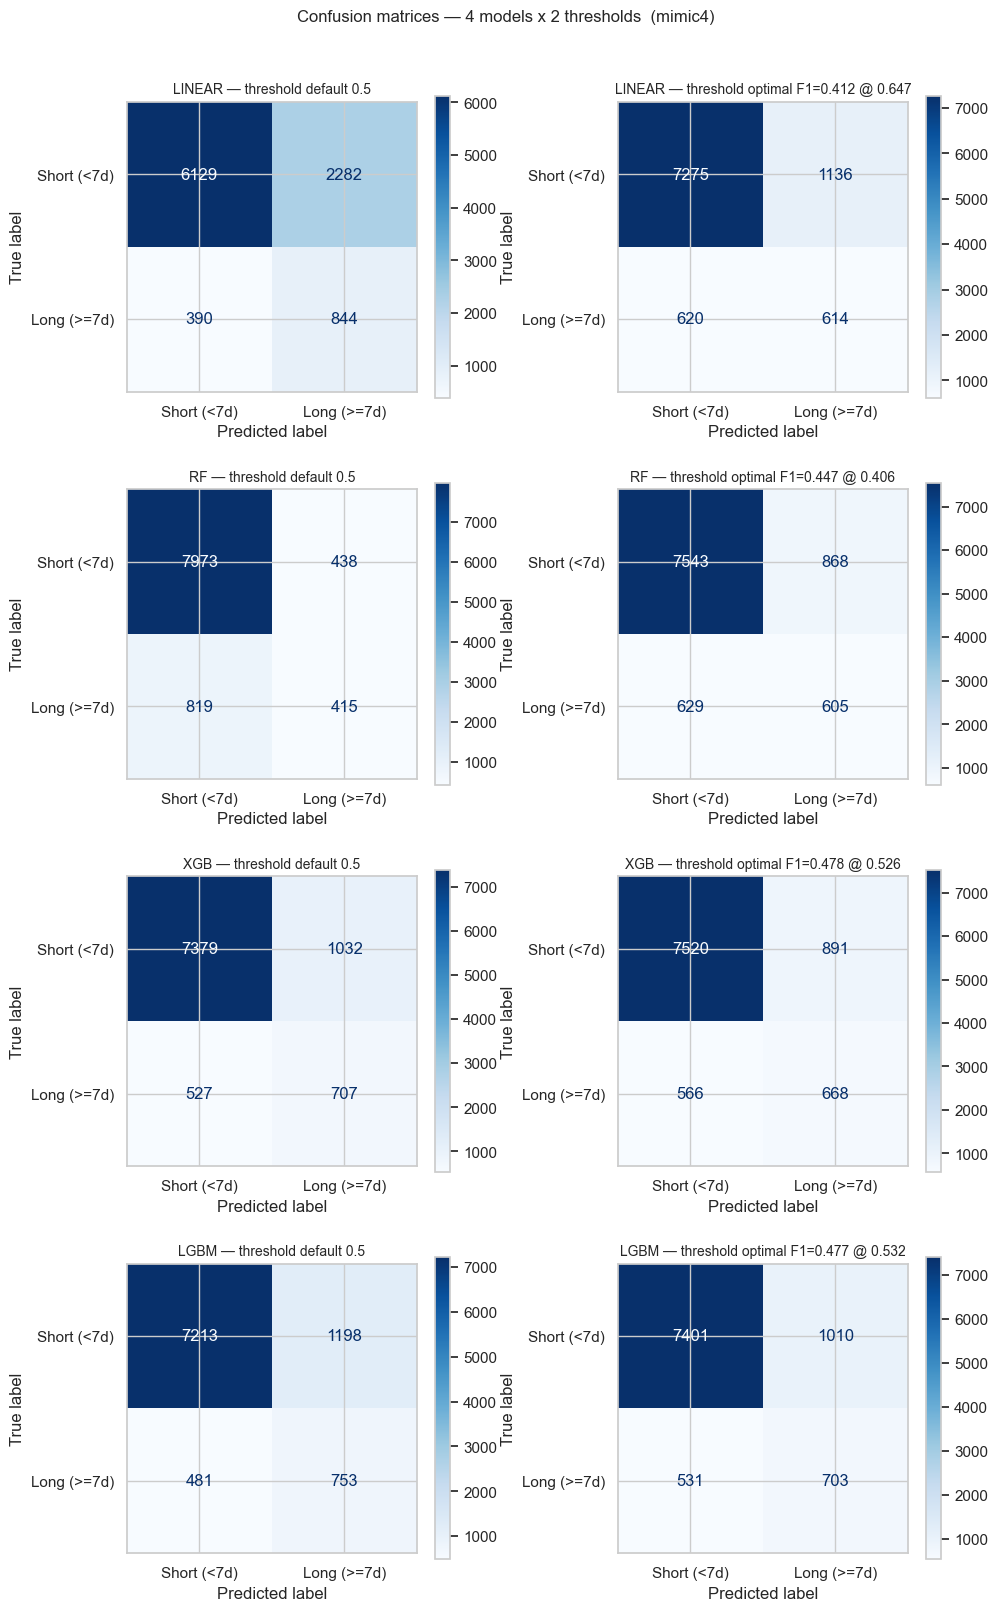

In [3]:
def find_optimal_f1_threshold(y_true, y_proba):
    """Find the probability threshold that maximizes F1."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1s)
    return thresholds[min(best_idx, len(thresholds) - 1)], f1s[best_idx]

fig, axes = plt.subplots(len(MODEL_NAMES), 2, figsize=(10, 4 * len(MODEL_NAMES)))

for i, m in enumerate(MODEL_NAMES):
    pipe = clf_pipes[m]
    y_proba = pipe.predict_proba(X_te_c)[:, 1]
    opt_thr, opt_f1 = find_optimal_f1_threshold(y_te_clf, y_proba)

    for j, (thr, label) in enumerate([(0.5, "default 0.5"), (opt_thr, f"optimal F1={opt_f1:.3f} @ {opt_thr:.3f}")]):
        y_pred = (y_proba >= thr).astype(int)
        cm = confusion_matrix(y_te_clf, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=["Short (<7d)", "Long (>=7d)"]).plot(ax=axes[i, j], cmap="Blues")
        axes[i, j].set_title(f"{m.upper()} — threshold {label}", fontsize=10)

fig.suptitle(f"Confusion matrices — 4 models x 2 thresholds  ({SOURCE})", y=1.01, fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"confusion_matrices_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Classification report

Precision, recall, and F1 for each class at the **optimal F1 threshold**. Key metrics:
- **Precision (long stay):** When the model says "long stay", how often is it right?
- **Recall (long stay):** Of all actual long stays, how many did the model catch?
- **F1:** Harmonic mean of precision and recall — balanced measure.

In [4]:
for m in MODEL_NAMES:
    pipe = clf_pipes[m]
    y_proba = pipe.predict_proba(X_te_c)[:, 1]
    opt_thr, _ = find_optimal_f1_threshold(y_te_clf, y_proba)
    y_pred = (y_proba >= opt_thr).astype(int)
    print(f"\n{'='*50}")
    print(f"  {m.upper()} — optimal threshold = {opt_thr:.3f}")
    print(f"{'='*50}")
    print(classification_report(y_te_clf, y_pred, target_names=["Short (<7d)", "Long (>=7d)"], digits=3))


  LINEAR — optimal threshold = 0.647
              precision    recall  f1-score   support

 Short (<7d)      0.921     0.865     0.892      8411
 Long (>=7d)      0.351     0.498     0.412      1234

    accuracy                          0.818      9645
   macro avg      0.636     0.681     0.652      9645
weighted avg      0.848     0.818     0.831      9645


  RF — optimal threshold = 0.406
              precision    recall  f1-score   support

 Short (<7d)      0.923     0.897     0.910      8411
 Long (>=7d)      0.411     0.490     0.447      1234

    accuracy                          0.845      9645
   macro avg      0.667     0.694     0.678      9645
weighted avg      0.857     0.845     0.851      9645




  XGB — optimal threshold = 0.526
              precision    recall  f1-score   support

 Short (<7d)      0.930     0.894     0.912      8411
 Long (>=7d)      0.428     0.541     0.478      1234

    accuracy                          0.849      9645
   macro avg      0.679     0.718     0.695      9645
weighted avg      0.866     0.849     0.856      9645




  LGBM — optimal threshold = 0.532
              precision    recall  f1-score   support

 Short (<7d)      0.933     0.880     0.906      8411
 Long (>=7d)      0.410     0.570     0.477      1234

    accuracy                          0.840      9645
   macro avg      0.672     0.725     0.691      9645
weighted avg      0.866     0.840     0.851      9645



## 4. Calibration plots

A well-calibrated model means: when it says "30 % chance of long stay", approximately 30 % of those patients actually stay long. The **diagonal line** is perfect calibration. Points above the diagonal = model is underconfident (actual probability higher than predicted). Below = overconfident.

Calibration matters for **clinical decision support**: a doctor needs to trust the probability, not just the yes/no prediction.

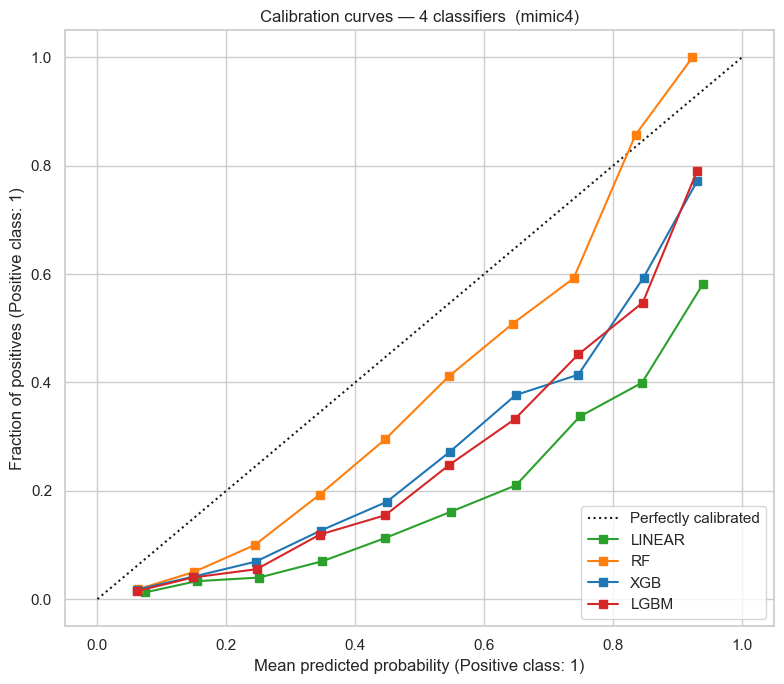

Interpretation:
  - Curve close to diagonal = well-calibrated
  - Above diagonal = underconfident (actual prob > predicted)
  - Below diagonal = overconfident (actual prob < predicted)


In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = {"linear": "#2ca02c", "rf": "#ff7f0e", "xgb": "#1f77b4", "lgbm": "#d62728"}

for m in MODEL_NAMES:
    pipe = clf_pipes[m]
    CalibrationDisplay.from_estimator(
        pipe, X_te_c, y_te_clf, n_bins=10, strategy="uniform",
        name=m.upper(), ax=ax, color=colors[m],
    )

ax.set_title(f"Calibration curves — 4 classifiers  ({SOURCE})")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"calibration_curves_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

print("Interpretation:")
print("  - Curve close to diagonal = well-calibrated")
print("  - Above diagonal = underconfident (actual prob > predicted)")
print("  - Below diagonal = overconfident (actual prob < predicted)")

## 5. Final comparison table

All models vs the mean predictor baseline, across both regression and classification. This is the **headline table** for the thesis Results section.

The mean predictor sets the floor (R² = 0, no learning). Every ML model should beat it substantially.

Regression (log1p target) — test set:


,MAE,RMSE,R2,MAE improvement vs mean
model,,,,
Mean predictor,2.553,5.300,-0.043,0.000
LINEAR,2.344,4.963,0.085,0.210
RF,2.254,4.847,0.128,0.300
XGB,2.169,4.684,0.185,0.384
LGBM,2.168,4.680,0.187,0.386



Classification (7-day threshold) — test set:


,AUC-PR,AUC-ROC,F1,Accuracy
model,,,,
Majority class,0.128,0.500,0.000,0.872
LINEAR,0.352,0.772,0.387,0.723
RF,0.424,0.801,0.398,0.870
XGB,0.462,0.822,0.476,0.838
LGBM,0.455,0.820,0.473,0.826



Saved to reports/tables/


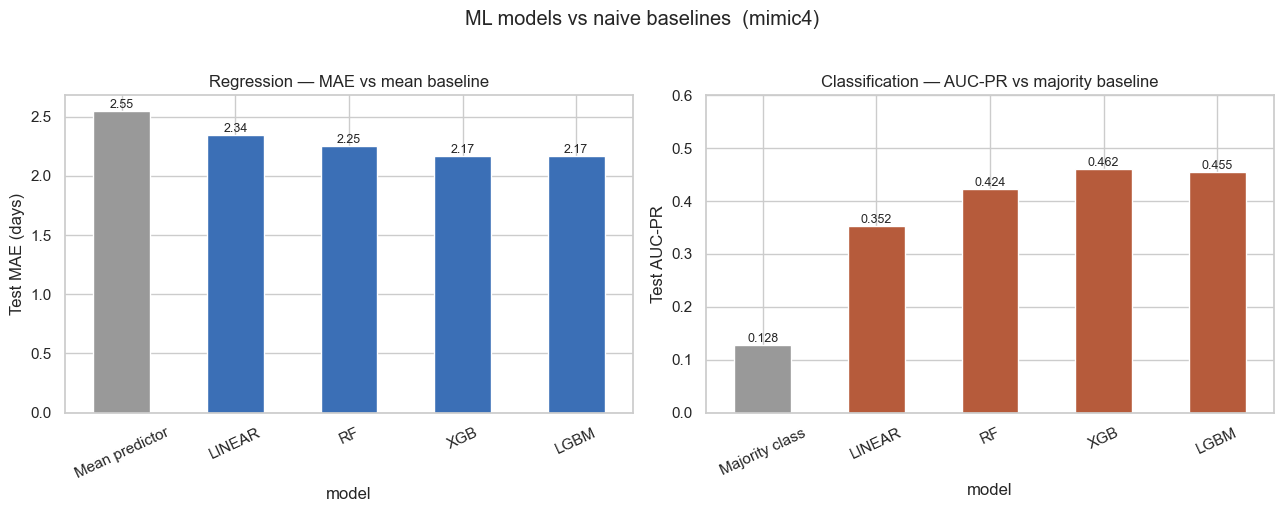

In [6]:
from src.models.train import regression_metrics, classification_metrics

# ── Regression comparison ──
reg_rows = [{"model": "Mean predictor", "MAE": mean_mae, "RMSE": mean_rmse, "R2": mean_r2}]
for m in MODEL_NAMES:
    pipe = reg_pipes[m]
    pred_days = to_days(pipe.predict(X_te), "regression")
    metrics = regression_metrics(y_te_days.values, pred_days)
    reg_rows.append({"model": m.upper(), "MAE": metrics["mae"], "RMSE": metrics["rmse"], "R2": metrics["r2"]})

reg_table = pd.DataFrame(reg_rows).set_index("model")
reg_table["MAE improvement vs mean"] = reg_table.loc["Mean predictor", "MAE"] - reg_table["MAE"]

print("Regression (log1p target) — test set:")
print("="*65)
display(reg_table.round(3))

# ── Classification comparison ──
clf_rows = [{"model": "Majority class", "AUC-PR": y_te_clf.mean(), "AUC-ROC": 0.5, "F1": 0.0, "Accuracy": (y_te_clf == 0).mean()}]
for m in MODEL_NAMES:
    pipe = clf_pipes[m]
    y_pred = pipe.predict(X_te_c)
    y_proba = pipe.predict_proba(X_te_c)[:, 1]
    metrics = classification_metrics(y_te_clf, y_pred, y_proba)
    clf_rows.append({"model": m.upper(), "AUC-PR": metrics["auc_pr"], "AUC-ROC": metrics["auc_roc"],
                     "F1": metrics["f1"], "Accuracy": metrics["accuracy"]})

clf_table = pd.DataFrame(clf_rows).set_index("model")

print("\nClassification (7-day threshold) — test set:")
print("="*65)
display(clf_table.round(3))

# ── Save for thesis ──
reg_table.round(3).to_csv(FIGURES_DIR.parent / "tables" / f"final_regression_comparison_{SOURCE}.csv")
clf_table.round(3).to_csv(FIGURES_DIR.parent / "tables" / f"final_classification_comparison_{SOURCE}.csv")
print(f"\nSaved to reports/tables/")

# ── Visual ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Regression MAE bar
ax = axes[0]
colors_reg = ["#999999"] + ["#3b6fb6"] * len(MODEL_NAMES)
reg_table["MAE"].plot.bar(ax=ax, color=colors_reg)
ax.set_ylabel("Test MAE (days)")
ax.set_title("Regression — MAE vs mean baseline")
ax.tick_params(axis="x", rotation=25)
for i, v in enumerate(reg_table["MAE"]):
    ax.annotate(f"{v:.2f}", (i, v), ha="center", va="bottom", fontsize=9)

# Classification AUC-PR bar
ax = axes[1]
colors_clf = ["#999999"] + ["#b65b3b"] * len(MODEL_NAMES)
clf_table["AUC-PR"].plot.bar(ax=ax, color=colors_clf)
ax.set_ylabel("Test AUC-PR")
ax.set_title("Classification — AUC-PR vs majority baseline")
ax.tick_params(axis="x", rotation=25)
ax.set_ylim(0, 0.6)
for i, v in enumerate(clf_table["AUC-PR"]):
    ax.annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=9)

fig.suptitle(f"ML models vs naive baselines  ({SOURCE})", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"final_comparison_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()